# Task 04 — Statistical Analysis and Hypothesis Testing

## Step 1: Dataset Loading and Initial Data Understanding

### Objective
The first step is to understand the structure and quality of the medical insurance dataset before applying any statistical test.

In this step, I will:
- Load the dataset
- Check its size and structure
- Identify numerical and categorical variables
- Check for missing values and duplicate records
- Generate basic descriptive statistics
- Inspect the categories of categorical variables

Understanding these points first is important because statistical methods should be selected according to the type and condition of the data.

### 1. Upload the Dataset

The dataset is provided as a CSV file. I will upload it to the Colab environment before loading it for analysis.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Medical Cost Personal.csv to Medical Cost Personal.csv


### 2. Load the Dataset

Pandas is used to read the CSV file and store it as a DataFrame, which allows the dataset to be inspected and analyzed using Python.

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("Medical Cost Personal.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 3. Check Dataset Dimensions

The shape of the dataset shows the number of observations (rows) and variables (columns). This gives an initial understanding of the amount of data available for analysis.


In [4]:
df.shape

(1338, 7)

### 4. Identify the Variables

Understanding the variables and their data types is important because the type of variables will influence which statistical tests can be applied later.

In [5]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

### 5. Inspect Data Types and Structure

The `info()` method shows the data type and number of non-null values for each variable. This helps verify whether the variables are stored in an appropriate format for analysis.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### 6. Check for Missing Values

Missing values can affect statistical analysis and may require imputation or removal. Therefore, they are checked before performing any statistical tests.

In [7]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### 7. Check for Duplicate Records

Duplicate records may give repeated observations unnecessary influence during analysis. I will check for duplicates before deciding whether any rows need to be removed.

In [8]:
df.duplicated().sum()

np.int64(1)

In [10]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


### 7.1 Remove Exact Duplicate

One exact duplicate record was identified during the data-quality check. Since the complete row is repeated, keeping both copies could give the same observation unnecessary weight in the statistical analysis.

I will remove the duplicate and verify that no duplicate records remain.

In [9]:
df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

### 8. Descriptive Statistics

Descriptive statistics provide a quick summary of the numerical variables in the dataset.

They help us understand:
- the average value using the mean
- the middle value using the median
- the spread using standard deviation
- the minimum and maximum values
- the distribution of values through quartiles

This initial summary is important before hypothesis testing because it helps us understand the behavior of variables such as `age`, `bmi`, `children`, and `charges`.

In [10]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


### Observation

The cleaned dataset contains 1,337 observations.

The average medical charge is approximately $13,279, while the median charge is approximately $9,386.

The maximum charge is approximately $63,770. This suggests that some customers have much higher medical costs than others and that the charges may be right-skewed.

The standard deviation of charges is approximately $12,110, showing that medical costs vary considerably across customers.

These findings will be considered when selecting and interpreting the statistical tests in the next steps.

### 9. Examine Categorical Variables

Categorical variables divide the observations into different groups. In this dataset, `sex`, `smoker`, and `region` are categorical variables.

Checking the number of observations in each category helps us understand the group sizes before comparing them statistically.

In [11]:
categorical_cols = ["sex", "smoker", "region"]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


sex:
sex
male      675
female    662
Name: count, dtype: int64

smoker:
smoker
no     1063
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


### Observation

The dataset contains 675 male and 662 female customers, so the two sex groups are relatively balanced.

There are 1,063 non-smokers and 274 smokers. The smoker group is smaller than the non-smoker group, which should be considered when comparing their medical charges.

The four regions contain 364, 325, 324, and 324 customers respectively. The regional groups are relatively similar in size, which is suitable for further comparison.


# Step 2: Formulating Statistical Questions and Hypotheses

The business scenario contains several questions about factors that may be related to medical insurance charges.

Before selecting statistical tests, each business question needs to be converted into a statistical question. This helps identify the variables involved, the type of comparison or relationship being tested, and the appropriate statistical method.

### Question 1: Do Smokers Have Higher Medical Charges?

The first business question is whether smoking status is associated with differences in medical insurance charges.

The variables involved are:

- `smoker` — categorical variable with two independent groups: yes and no
- `charges` — numerical variable representing medical insurance cost

The purpose is to determine whether the difference in charges between smokers and non-smokers is statistically significant rather than simply comparing their averages.

### Hypotheses

Null Hypothesis (H0):

There is no statistically significant difference in medical charges between smokers and non-smokers.

Alternative Hypothesis (H1):

There is a statistically significant difference in medical charges between smokers and non-smokers.

### Question 2: Is BMI Related to Medical Charges?

The second business question examines whether BMI is associated with medical insurance charges.

The variables involved are:

- `bmi` — numerical variable
- `charges` — numerical variable

Unlike the smoking question, this is not a comparison between two groups. Both variables are numerical, so the analysis will focus on whether a statistical relationship exists between them.

### Hypotheses

Null Hypothesis (H0):

There is no statistically significant relationship between BMI and medical charges.

Alternative Hypothesis (H1):

There is a statistically significant relationship between BMI and medical charges.

### Question 3: Do Medical Charges Differ Across Regions?

The third business question examines whether average medical charges differ across the four residential regions.

The variables involved are:

- `region` — categorical variable with four independent groups
- `charges` — numerical variable

Since there are more than two groups, a method designed for multiple-group comparison will be considered.

### Hypotheses

Null Hypothesis (H0):

There is no statistically significant difference in medical charges across the four regions.

Alternative Hypothesis (H1):

At least one region has a statistically different medical charge distribution or mean compared with another region.

### Test Selection Overview

The three questions require different statistical approaches because the variables and comparison structures are different.

- Smoking status vs charges involves two independent groups, so a two-group comparison test will be considered.
- BMI vs charges involves two numerical variables, so a correlation-based analysis will be considered.
- Region vs charges involves four independent groups, so a multiple-group comparison test such as ANOVA will be considered.

The final test will be selected after checking the relevant assumptions and characteristics of the data.

# Step 3: Smoking Status and Medical Charges

### 3.1 Compare Medical Charges by Smoking Status

Before applying a hypothesis test, I will first compare the medical charges of smokers and non-smokers using basic descriptive statistics.

This provides an initial view of the differences between the two groups. The comparison includes the number of observations, mean, median, and standard deviation of medical charges.

In [12]:
df.groupby("smoker")["charges"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
smoker,,,,
no,1063,8440.660307,7345.72660,5992.973800
yes,274,32050.231832,34456.34845,11541.547176


### Observation

The descriptive comparison shows a clear difference in medical charges between the two groups.

The average charge for non-smokers is approximately $8,441, while the average charge for smokers is approximately $32,050. The median charges show a similar pattern, with non-smokers at approximately $7,346 and smokers at approximately $34,456.

The smoker group also has a higher standard deviation, indicating greater variation in medical charges.

These results suggest that smokers have substantially higher medical charges in this dataset. However, descriptive statistics alone cannot determine whether this difference is statistically significant, so an appropriate hypothesis test will be performed after checking the data characteristics and assumptions.

### 3.2 Examine the Distribution of Medical Charges

A boxplot is used to visually compare the distribution of medical charges for smokers and non-smokers.

It helps identify the median, spread of the data, and potential outliers in each group. This information is useful before selecting a statistical test because the distribution and presence of extreme values can affect the choice of test.

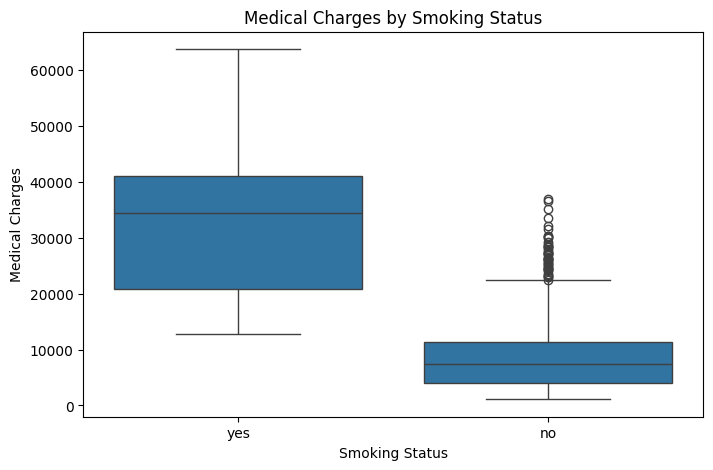

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="smoker", y="charges")

plt.title("Medical Charges by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Medical Charges")
plt.show()

### Observation

The boxplot shows a clear difference in medical charges between smokers and non-smokers.

The smoker group has a much higher median charge and its distribution is positioned considerably above the non-smoker group.

Several high-value observations are visible in the non-smoker group as potential outliers. These observations will not be removed automatically because they may represent genuine high medical costs.

The visual comparison supports the difference observed in the descriptive statistics. However, a statistical test is still required to determine whether the difference is statistically significant.

### 3.3 Check Distribution and Test Assumptions

Before selecting the statistical test, the distribution of medical charges within each smoking group needs to be examined.

The main factors considered are the distribution of the numerical variable, the presence of outliers, and whether the two groups are independent.

These checks help determine whether a parametric test such as an independent t-test is appropriate or whether a non-parametric alternative such as the Mann-Whitney U test should be considered.

In [14]:
df.groupby("smoker")["charges"].skew()

,charges
smoker,
no,1.538363
yes,0.128217


### 3.4 Check Equality of Variances

The variability of medical charges may differ between smokers and non-smokers. Before applying a parametric two-group test, I will check whether the two groups have similar variances.

Levene's test is used for this purpose. It tests whether the variances of the groups are statistically different.

In [15]:
from scipy.stats import levene

smoker_charges = df.loc[df["smoker"] == "yes", "charges"]
non_smoker_charges = df.loc[df["smoker"] == "no", "charges"]

levene_result = levene(smoker_charges, non_smoker_charges)

print("Levene's test statistic:", levene_result.statistic)
print("p-value:", levene_result.pvalue)

Levene's test statistic: 332.47137394800666
p-value: 1.670117565125241e-66


### Observation

Levene's test produced a test statistic of approximately 332.47 with a p-value much smaller than 0.05.

Therefore, the null hypothesis of equal variances is rejected. This indicates that the variability of medical charges is statistically different between smokers and non-smokers.

Since the equal-variance assumption is not supported, a standard independent t-test that assumes equal variances would not be the preferred choice. If a t-test is used, Welch's t-test is more appropriate because it does not assume equal population variances.

### 3.5 Select the Appropriate Statistical Test

The analysis involves two independent groups and a numerical outcome, so a two-group comparison test is required.

The Levene's test showed that the group variances are significantly different. Therefore, the standard independent t-test with an equal-variance assumption is not appropriate.

Welch's t-test is selected as the primary test because it compares group means without assuming equal population variances.

Because the charge distribution is also skewed and contains potential outliers, the Mann-Whitney U test will be used as a non-parametric supporting analysis. Comparing both results provides a more robust interpretation of the group difference.

### 3.6 Welch's t-test

Welch's t-test evaluates whether the mean medical charges of smokers and non-smokers are statistically different while allowing the two groups to have unequal variances.

Null Hypothesis (H0):

There is no significant difference in mean medical charges between smokers and non-smokers.

Alternative Hypothesis (H1):

There is a significant difference in mean medical charges between smokers and non-smokers.

In [16]:
from scipy.stats import ttest_ind

welch_result = ttest_ind(
    smoker_charges,
    non_smoker_charges,
    equal_var=False
)

print("Welch's t-test statistic:", welch_result.statistic)
print("p-value:", welch_result.pvalue)

Welch's t-test statistic: 32.7423097372529
p-value: 6.261720774727631e-103


### Observation

Welch's t-test produced a test statistic of approximately 32.74 and a p-value much smaller than 0.05.

Therefore, the null hypothesis is rejected. This provides strong statistical evidence that the mean medical charges differ between smokers and non-smokers.

The result is consistent with the descriptive analysis, where smokers had a much higher average charge than non-smokers.

This result shows a statistically significant difference, but statistical significance alone does not indicate how large or practically important the difference is. Effect size and confidence interval will be calculated next.

### 3.7 Effect Size

Statistical significance tells us whether the observed difference is unlikely to be due to random variation, but it does not show the magnitude of the difference.

Cohen's d is used to measure the standardized difference between the two group means. A larger absolute value indicates a larger practical difference between the groups.

In [17]:
mean_smoker = smoker_charges.mean()
mean_non_smoker = non_smoker_charges.mean()

sd_smoker = smoker_charges.std()
sd_non_smoker = non_smoker_charges.std()

n_smoker = len(smoker_charges)
n_non_smoker = len(non_smoker_charges)

pooled_sd = np.sqrt(
    ((n_smoker - 1) * sd_smoker**2 +
     (n_non_smoker - 1) * sd_non_smoker**2)
    / (n_smoker + n_non_smoker - 2)
)

cohens_d = (mean_smoker - mean_non_smoker) / pooled_sd

print("Cohen's d:", cohens_d)

Cohen's d: 3.1602902766581233


### Observation

Cohen's d was approximately 3.16, indicating a very large standardized difference in medical charges between smokers and non-smokers.

This supports the descriptive and hypothesis-testing results, showing that the difference is not only statistically significant but also large in magnitude.

The result indicates a strong association between smoking status and medical charges in this dataset. However, this analysis does not establish that smoking directly causes the difference in charges.

### 3.8 Confidence Interval for the Mean Difference

A confidence interval provides a range of plausible values for the population mean difference between smokers and non-smokers.

A 95% confidence interval will be calculated for the difference in mean medical charges. This gives additional information about the size and uncertainty of the observed difference.

In [18]:
from scipy.stats import t

mean_diff = mean_smoker - mean_non_smoker

se_diff = np.sqrt(
    (sd_smoker**2 / n_smoker) +
    (sd_non_smoker**2 / n_non_smoker)
)

df_welch = (
    ((sd_smoker**2 / n_smoker) +
     (sd_non_smoker**2 / n_non_smoker))**2
    /
    (
        ((sd_smoker**2 / n_smoker)**2 / (n_smoker - 1))
        +
        ((sd_non_smoker**2 / n_non_smoker)**2 / (n_non_smoker - 1))
    )
)

critical_value = t.ppf(0.975, df_welch)

ci_lower = mean_diff - critical_value * se_diff
ci_upper = mean_diff + critical_value * se_diff

print("Mean difference:", mean_diff)
print("95% CI:", (ci_lower, ci_upper))

Mean difference: 23609.571525023905
95% CI: (np.float64(22190.79008570521), np.float64(25028.3529643426))


### Observation

The estimated difference in mean medical charges between smokers and non-smokers is approximately $23,609.57.

The 95% confidence interval for this difference ranges from approximately $22,190.79 to $25,028.35. Since the interval does not include zero, it supports the conclusion that the mean charges differ between the two groups.

The interval also shows that the difference is substantial in practical terms, not only statistically significant.

### 3.9 Mann-Whitney U Test

Because the charge distribution is skewed and contains potential outliers, the Mann-Whitney U test is used as a non-parametric supporting analysis.

This test compares the distributions of medical charges between the two independent groups without relying on the same distributional assumptions as a parametric t-test.

The result will be compared with the Welch's t-test to assess whether the overall conclusion is consistent.

In [19]:
from scipy.stats import mannwhitneyu

mannwhitney_result = mannwhitneyu(
    smoker_charges,
    non_smoker_charges,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", mannwhitney_result.statistic)
print("p-value:", mannwhitney_result.pvalue)

Mann-Whitney U statistic: 283859.0
p-value: 5.74701188239214e-130


### Observation

The Mann-Whitney U test produced a U statistic of 283,859 and a p-value much smaller than 0.05.

Therefore, the null hypothesis is rejected, indicating a statistically significant difference in the distribution of medical charges between smokers and non-smokers.

This result is consistent with the Welch's t-test, which also found a statistically significant difference. The agreement between the two tests strengthens the evidence that smoking status is associated with substantially different medical charges in this dataset.


### 3.10 Final Conclusion: Smoking Status and Medical Charges

The analysis provides strong evidence of a substantial difference in medical charges between smokers and non-smokers.

Smokers had an average charge of approximately $32,050 compared with $8,441 for non-smokers, giving an observed mean difference of approximately $23,610.

Welch's t-test found a statistically significant difference, while the Mann-Whitney U test produced the same overall conclusion. The Cohen's d of approximately 3.16 indicates a very large effect size.

The 95% confidence interval for the mean difference ranged from approximately $22,191 to $25,028.

Overall, smoking status shows a strong association with medical charges in this dataset. However, these statistical results do not by themselves establish that smoking directly causes higher insurance charges.

# Step 4: BMI and Medical Charges

The second business question investigates whether BMI is statistically associated with medical insurance charges.

Unlike the smoking analysis, this question involves two numerical variables: `bmi` and `charges`. Therefore, the analysis focuses on measuring the strength and direction of their relationship rather than comparing separate groups.

The analysis will examine the relationship visually and statistically before drawing a business conclusion.


### 4.1 Variables and Statistical Question

The variables used in this analysis are:

- `bmi`: numerical variable representing body mass index
- `charges`: numerical variable representing medical insurance costs

Statistical question:

Is there a statistically significant relationship between BMI and medical charges?

H0: There is no statistically significant relationship between BMI and medical charges.

H1: There is a statistically significant relationship between BMI and medical charges.

### 4.2 Visualize the Relationship Between BMI and Charges

A scatter plot is used to visually examine the relationship between BMI and medical charges.

The plot helps identify whether the variables show an increasing or decreasing pattern, how strong the relationship appears to be, and whether unusual observations may influence the relationship.

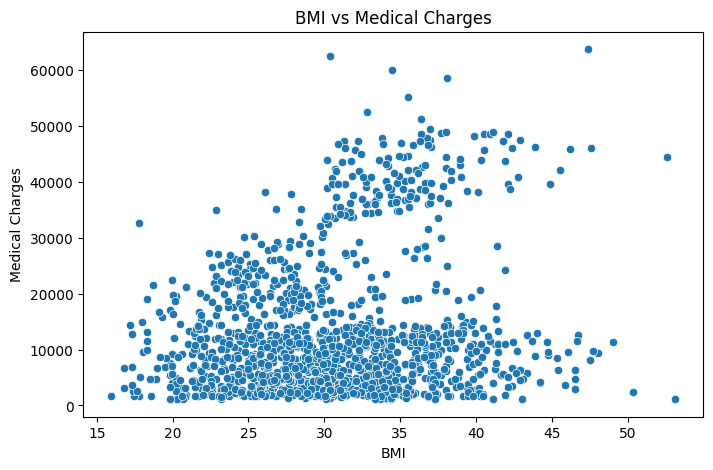

In [20]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="bmi", y="charges")

plt.title("BMI vs Medical Charges")
plt.xlabel("BMI")
plt.ylabel("Medical Charges")
plt.show()

### Observation

The scatter plot shows a generally positive pattern between BMI and medical charges, although the relationship is not perfectly linear.

Customers with similar BMI values can have substantially different medical charges, suggesting that BMI alone does not fully explain the variation in charges.

The visual pattern provides an initial indication of an association, but a correlation analysis is required to measure the strength and statistical significance of this relationship.

### 4.3 Select the Correlation Method

Both BMI and medical charges are numerical variables, so correlation analysis is appropriate.

Pearson correlation measures the strength of a linear relationship, while Spearman correlation measures the strength of a monotonic relationship using ranked data.

Because medical charges are skewed and the scatter plot does not show a perfectly linear relationship, Spearman correlation will be used as the primary method. Pearson correlation will also be calculated for comparison.

In [21]:
from scipy.stats import pearsonr, spearmanr

pearson_result = pearsonr(df["bmi"], df["charges"])
spearman_result = spearmanr(df["bmi"], df["charges"])

print("Pearson correlation:", pearson_result.statistic)
print("Pearson p-value:", pearson_result.pvalue)

print("\nSpearman correlation:", spearman_result.statistic)
print("Spearman p-value:", spearman_result.pvalue)

Pearson correlation: 0.19840083122624938
Pearson p-value: 2.4680404264513685e-13

Spearman correlation: 0.11958495819244366
Spearman p-value: 1.1637179203181515e-05


### Observation

Both Pearson and Spearman correlations are positive and statistically significant.

The Spearman correlation is approximately 0.12 with a p-value below 0.05, indicating a statistically significant positive association between BMI and medical charges. However, the correlation is weak in magnitude.

Pearson correlation also shows a weak positive relationship. The consistency in direction and significance between both methods supports the presence of an association, while the low correlation values indicate that BMI alone has limited ability to explain the variation in medical charges.

### 4.4 95% Confidence Interval for Pearson Correlation

A 95% confidence interval will be calculated for the Pearson correlation to quantify the uncertainty around the sample correlation.

This provides a plausible range for the population correlation and gives more information than the correlation coefficient alone.

In [22]:
from scipy.stats import pearsonr

pearson_result = pearsonr(df["bmi"], df["charges"])

ci = pearson_result.confidence_interval(confidence_level=0.95)

print("Pearson correlation:", pearson_result.statistic)
print("95% CI:", (ci.low, ci.high))

Pearson correlation: 0.19840083122624938
95% CI: (np.float64(0.14634647963989506), np.float64(0.2493594891592873))


### Observation

The Pearson correlation is approximately 0.20, indicating a weak positive relationship between BMI and medical charges.

The 95% confidence interval ranges from approximately 0.15 to 0.25 and does not include zero, which supports the presence of a positive association in the population.

Although the relationship is statistically significant, its relatively small correlation coefficient indicates that BMI alone has limited ability to explain the variation in medical charges.

### 4.5 Final Conclusion: BMI and Medical Charges

The analysis found a statistically significant positive association between BMI and medical charges.

The Spearman correlation was approximately 0.12, while the Pearson correlation was approximately 0.20. Both relationships were statistically significant, but their small magnitudes indicate that the association is weak.

The 95% confidence interval for the Pearson correlation was approximately 0.15 to 0.25, which does not include zero.

Therefore, BMI is associated with medical charges in this dataset, but BMI alone is not a strong predictor of insurance costs. Other factors are likely responsible for a substantial portion of the variation in charges.

# Step 5: Region and Medical Charges

The third statistical question examines whether medical charges differ across the four residential regions.

The `region` variable contains four independent groups: southeast, southwest, northwest, and northeast. The outcome variable, `charges`, is numerical.

Because more than two independent groups are being compared, a one-way ANOVA will be considered. The relevant assumptions will be checked before interpreting the test result.

### 5.1 Compare Medical Charges Across Regions

Before applying ANOVA, descriptive statistics are used to compare the medical charges across the four regions.

This provides an initial understanding of the group sizes, average charges, median charges, and variability.

In [23]:
df.groupby("region")["charges"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
region,,,,
northeast,324,13406.384516,10057.652025,11255.803066
northwest,324,12450.840844,8976.977250,11073.125699
southeast,364,14735.411438,9294.131950,13971.098589
southwest,325,12346.937377,8798.593000,11557.179101


### Observation

The descriptive statistics show some differences in medical charges across the four regions.

The Southeast region has the highest mean charge at approximately $14,735, while the Southwest has the lowest mean at approximately $12,347.

The standard deviations also show noticeable variation within the groups, particularly in the Southeast region.

These differences provide an initial indication that charges may vary by region, but a statistical test is required to determine whether the observed differences are statistically significant.

### 5.2 One-Way ANOVA

A one-way ANOVA is appropriate because the analysis compares a numerical outcome across four independent categorical groups.

The test evaluates whether there is evidence that the mean medical charges differ across the regions.

H0: The mean medical charges are equal across all four regions.

H1: At least one regional mean is different.

In [24]:
from scipy.stats import levene

region_groups = [
    group["charges"].values
    for _, group in df.groupby("region")
]

levene_region = levene(*region_groups)

print("Levene's test statistic:", levene_region.statistic)
print("p-value:", levene_region.pvalue)

Levene's test statistic: 5.5534798606999125
p-value: 0.0008689544824002284


### Observation

Levene's test produced a test statistic of approximately 5.55 with a p-value of 0.00087.

Since the p-value is below 0.05, the null hypothesis of equal variances is rejected. This indicates that the variability of medical charges differs significantly across the four regions.

Therefore, the standard one-way ANOVA that assumes equal variances is not the preferred approach. A variance-robust alternative will be used for the regional comparison.

### 5.4 Welch's ANOVA

Because the equality-of-variance assumption was not supported by Levene's test, Welch's ANOVA is used instead of the standard one-way ANOVA.

Welch's ANOVA tests whether the group means differ while being more robust to unequal variances.

H0: The mean medical charges are equal across the four regions.

H1: At least one regional mean is different.

In [25]:
from scipy.stats import f_oneway

welch_anova = f_oneway(
    *region_groups,
    equal_var=False
)

print("Welch's ANOVA statistic:", welch_anova.statistic)
print("p-value:", welch_anova.pvalue)

Welch's ANOVA statistic: 2.5662227136014413
p-value: 0.05348899434656477


### Observation

Welch's ANOVA produced a test statistic of approximately 2.57 with a p-value of 0.0535.

Since the p-value is slightly above the 0.05 significance level, the null hypothesis is not rejected. Therefore, there is insufficient statistical evidence at the 5% significance level to conclude that mean medical charges differ significantly across the four regions.

Although the descriptive statistics show differences in regional mean charges, these differences are not statistically significant at the selected significance level.

### 5.5 Effect Size

Statistical significance alone does not describe the practical importance of a group difference.

Eta-squared (η²) is used to estimate the proportion of variation in medical charges associated with regional differences.

This helps determine whether region explains a meaningful amount of variation in charges, even when the hypothesis test is not statistically significant.

In [26]:
grand_mean = df["charges"].mean()

ss_between = sum(
    len(group) * (group["charges"].mean() - grand_mean) ** 2
    for _, group in df.groupby("region")
)

ss_total = ((df["charges"] - grand_mean) ** 2).sum()

eta_squared = ss_between / ss_total

print("Eta-squared (η²):", eta_squared)

Eta-squared (η²): 0.006542376581730343


### Observation

The eta-squared value is approximately 0.0065, indicating that regional differences are associated with only about 0.65% of the variation in medical charges.

This represents a very small practical effect. Combined with the Welch's ANOVA p-value of 0.0535, the results do not provide sufficient evidence of a meaningful regional difference in medical charges at the 5% significance level.

### 5.6 Final Conclusion: Region and Medical Charges

The descriptive analysis showed some differences in average medical charges across regions, with the Southeast having the highest mean and the Southwest having the lowest.

However, Levene's test indicated unequal variances, so Welch's ANOVA was selected instead of the standard one-way ANOVA.

Welch's ANOVA produced a p-value of approximately 0.0535, which is slightly above the 0.05 significance level. Therefore, there is insufficient statistical evidence to conclude that mean medical charges differ significantly across the four regions.

The eta-squared value of approximately 0.0065 also indicates a very small practical effect, with region associated with only about 0.65% of the variation in charges.

Overall, region does not appear to be an important standalone factor for explaining medical charges in this dataset.

### 5.7 Multiple Comparison Correction

When several pairwise statistical tests are performed, the probability of obtaining at least one false-positive result increases.

Bonferroni correction controls this risk by adjusting the significance threshold according to the number of comparisons.

For four regions, there are six possible pairwise comparisons. Therefore:

Adjusted alpha = 0.05 / 6 = 0.00833

A pairwise result would be considered statistically significant only if its p-value is below 0.00833.

In [27]:
from itertools import combinations

regions = df["region"].unique()

comparisons = list(combinations(regions, 2))

alpha = 0.05
adjusted_alpha = alpha / len(comparisons)

print("Number of pairwise comparisons:", len(comparisons))
print("Bonferroni adjusted alpha:", adjusted_alpha)
print("\nComparisons:")

for pair in comparisons:
    print(pair)

Number of pairwise comparisons: 6
Bonferroni adjusted alpha: 0.008333333333333333

Comparisons:
('southwest', 'southeast')
('southwest', 'northwest')
('southwest', 'northeast')
('southeast', 'northwest')
('southeast', 'northeast')
('northwest', 'northeast')


### Observation

With four regional groups, six pairwise comparisons are possible. Bonferroni correction reduces the significance threshold from 0.05 to approximately 0.0083.

This adjustment helps control the overall false-positive risk if pairwise tests are performed.

Since the overall Welch's ANOVA was not statistically significant at the 5% level, pairwise comparisons are treated as exploratory rather than as confirmatory evidence of regional differences.

# Step 6: Statistical Analysis Summary

The following table summarizes the main hypothesis tests performed in the analysis. The tests were selected based on the type of variables, number of groups, and relevant assumptions.

In [28]:
summary = pd.DataFrame({
    "Analysis": [
        "Smoking Status vs Charges",
        "BMI vs Charges",
        "Region vs Charges"
    ],
    "Method": [
        "Welch's t-test",
        "Spearman correlation",
        "Welch's ANOVA"
    ],
    "p_value": [
        welch_result.pvalue,
        spearman_result.pvalue,
        welch_anova.pvalue
    ],
    "Decision": [
        "Significant",
        "Significant",
        "Not Significant"
    ]
})

summary

,Analysis,Method,p_value,Decision
0,Smoking Status vs Charges,Welch's t-test,6.261721e-103,Significant
1,BMI vs Charges,Spearman correlation,1.163718e-05,Significant
2,Region vs Charges,Welch's ANOVA,5.348899e-02,Not Significant


### 6.1 Key Findings

1. Smoking status showed a statistically significant and very large difference in medical charges. Smokers had substantially higher average charges than non-smokers.

2. BMI showed a statistically significant positive association with charges, but the relationship was weak. Therefore, BMI alone does not explain a large portion of charge variation.

3. Region did not show statistically significant differences in mean charges at the 5% significance level. The effect size was also very small, indicating limited practical importance.

Overall, smoking status showed the strongest association with medical charges among the factors analyzed, while BMI had a weaker relationship and region showed little evidence of an important standalone effect.

# Business Recommendations

Based on the statistical analysis:

1. Smoking status should be considered an important risk-related variable because smokers showed substantially higher medical charges.

2. BMI may provide some information about medical costs, but its relationship with charges was weak. It should not be considered independently.

3. Region showed a very small practical effect and no statistically significant difference in mean charges. Therefore, region should not be treated as a major standalone factor.

These findings should be considered alongside other relevant factors and business or regulatory requirements when making insurance decisions.

# Final Conclusion

This analysis applied hypothesis testing, correlation analysis, confidence intervals, effect sizes, and multiple-comparison considerations to investigate medical insurance charges.

Smoking status showed the strongest association with charges, with a statistically significant difference and a very large effect size. BMI showed a statistically significant but weak positive association, while region showed no statistically significant difference and a very small practical effect.

Overall, the results show why statistical significance should be interpreted together with effect size, confidence intervals, assumptions, and business context. The findings describe associations in this dataset and should not be interpreted as proof of causation.